# # Notebook 04 — Vision Transformer (ViT-B/16)
# **DeepLense GSoC 2026 Evaluation**
# Fine-tune ViT-B/16 with AdamW + CosineAnnealingLR.
# Complementary failure modes vs ResNet motivate the Ensemble in NB05.

In [1]:
# %% [Cell 1: Mount Google Drive & Set Workspace]
import os, sys
 
from google.colab import drive
drive.mount('/content/drive')
 
BASE_DIR = "/content/drive/My Drive/DeepLense_GSoC_Data"
SRC_DIR  = os.path.join(BASE_DIR, "src")
 
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)
 
print(f"✅ Workspace : {BASE_DIR}")
print(f"✅ src/ path : {SRC_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Workspace : /content/drive/My Drive/DeepLense_GSoC_Data
✅ src/ path : /content/drive/My Drive/DeepLense_GSoC_Data/src


In [2]:
# %% [Cell 2: WandB Authentication — Key loaded from .env file]
import os
import wandb
from dotenv import load_dotenv

load_dotenv(os.path.join(BASE_DIR, ".env"))
wandb.login(key=os.getenv("WANDB_API_KEY"))
print("✅ WandB authenticated successfully")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: diminiax (diminiax-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ WandB authenticated successfully


In [3]:
# %% [Cell 3: Install Dependencies & Verify GPU]
# ── Install from pinned requirements — fixes numpy binary incompatibility ─
!pip install -q -r "/content/drive/My Drive/DeepLense_GSoC_Data/requirements.txt"

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Device : {device}")
if device.type == 'cuda':
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")


🖥️  Device : cuda
   GPU    : Tesla T4


In [4]:
# %% [Cell 3: Imports & Reproducibility Seed]
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
 
from dataset import get_dataloaders, stage_data_locally
from models  import ViTChampion
from metrics import (
    save_confusion_matrix,
    generate_classification_report,
    plot_multiclass_roc_auc,
    plot_learning_curves,
)
 
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
 
set_seed(42)
print("✅ Seed set to 42 — deterministic training enabled")

✅ Seed set to 42 — deterministic training enabled


In [5]:
# %% [Cell 4: Stage Data & Build DataLoaders]
ZIP_PATH = os.path.join(BASE_DIR, "dataset.zip")
CSV_NAME = "metadata.csv"
 
staged_dir = stage_data_locally(ZIP_PATH)
data_dir   = staged_dir if staged_dir else BASE_DIR
csv_path   = os.path.join(data_dir, CSV_NAME)
 
print(f"📂 Data directory : {data_dir}")
print(f"📄 CSV path       : {csv_path}")
 
# ── Build DataLoaders ─────────────────────────────────────────────────────
# ViT requires 224×224 RGB — same as NB02/NB03
# augment=False — ViT is already slow to train, we keep this clean
# The global attention mechanism gives ViT rotational sensitivity anyway
# FIX v1: train and val were using the SAME vit_transform — leakage fixed
# FIX v2: get_dataloaders now returns a 6-tuple (adds test_loader + test_df)
train_loader, val_loader, _, train_df, val_df, _ = get_dataloaders(
    csv_path   = csv_path,
    base_dir   = data_dir,
    mode       = 'RGB',
    image_size = 224,
    batch_size = 32,
    augment    = False,
)
 
print(f"\n✅ Train batches : {len(train_loader)} ({len(train_df)} images)")
print(f"✅ Val batches   : {len(val_loader)}   ({len(val_df)} images)")

✅ Local staging already complete at: /content/local_dataset
📂 Data directory : /content/local_dataset
📄 CSV path       : /content/local_dataset/metadata.csv

📊 Dataset Class Distribution:
   cdm        :   500 samples  (33.3%)
   no_sub     :   500 samples  (33.3%)
   vortex     :   500 samples  (33.3%)
   TOTAL      :  1500 samples

✅ Split — Train: 1050 | Val: 225 | Test: 225

✅ Train batches : 32 (1050 images)
✅ Val batches   : 8   (225 images)


In [6]:
# %% [Cell 5: Model, Loss, Optimizer, Scheduler]
# ── Model ─────────────────────────────────────────────────────────────────
# ViT-B/16: 197 tokens (196 patches + 1 CLS token), 12 attention heads,
# 768 embedding dim, 12 transformer blocks.
# The classification head (model.heads.head) is replaced with a 3-class linear layer.
model = ViTChampion(num_classes=3).to(device)
print(f"🧠 Model      : ViT-B/16 (ImageNet weights)")
print(f"   Input      : (B, 3, 224, 224) — RGB, ImageNet-normalised")
print(f"   Patches    : 14×14 grid = 196 tokens + 1 CLS token")
print(f"   Strategy   : Full fine-tuning with very low LR")
 
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Total params    : {total_params:,}")
print(f"   Trainable params: {trainable_params:,}")
 
criterion = nn.CrossEntropyLoss()
 
# ── Optimizer — AdamW is MANDATORY for ViT ────────────────────────────────
# AdamW = Adam + decoupled weight decay. This is not optional for transformers.
# Plain Adam on a ViT leads to poor regularisation of attention weights,
# causing overfitting. weight_decay=0.01 is the standard ViT fine-tuning value.
#
# LR = 5e-5 (half of NB02's 1e-4).
# ViT has 86M parameters vs ResNet's 11M — a higher LR causes catastrophic
# forgetting of the self-attention patterns learned on ImageNet.
LEARNING_RATE = 5e-5
WEIGHT_DECAY  = 0.01
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
 
# ── LR Scheduler — CosineAnnealingLR is CRITICAL for ViT ─────────────────
# ViT is extremely sensitive to learning rate in later epochs.
# Without decay, the attention weights oscillate and val_acc plateaus early.
# CosineAnnealingLR smoothly reduces LR to near-zero — standard ViT recipe.
EPOCHS    = 15   # More epochs than NB02 — ViT converges slower than ResNet
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-8
)
 
print(f"\n⚙️  Optimizer  : AdamW (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})")
print(f"⚙️  Scheduler  : CosineAnnealingLR (T_max={EPOCHS}, eta_min=1e-8)")
print(f"⚙️  Epochs     : {EPOCHS}")
print(f"\n💡 Why AdamW + CosineAnnealingLR:")
print(f"   ViT attention weights need decoupled weight decay (AdamW)")
print(f"   and smooth LR decay (Cosine) to avoid oscillation late in training.")
print(f"   v1 used plain Adam with no scheduler — this is why ViT only hit 60%.")
 
ASSETS_DIR  = os.path.join(BASE_DIR, "assets")
WEIGHTS_DIR = os.path.join(BASE_DIR, "weights")
os.makedirs(ASSETS_DIR,  exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 168MB/s] 


🧠 Model      : ViT-B/16 (ImageNet weights)
   Input      : (B, 3, 224, 224) — RGB, ImageNet-normalised
   Patches    : 14×14 grid = 196 tokens + 1 CLS token
   Strategy   : Full fine-tuning with very low LR
   Total params    : 85,800,963
   Trainable params: 85,800,963

⚙️  Optimizer  : AdamW (lr=5e-05, wd=0.01)
⚙️  Scheduler  : CosineAnnealingLR (T_max=15, eta_min=1e-8)
⚙️  Epochs     : 15

💡 Why AdamW + CosineAnnealingLR:
   ViT attention weights need decoupled weight decay (AdamW)
   and smooth LR decay (Cosine) to avoid oscillation late in training.
   v1 used plain Adam with no scheduler — this is why ViT only hit 60%.


In [7]:
# %% [Cell 6: Training Loop]
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
 
best_val_acc = 0.0
best_epoch   = 0
best_weights = None
 
print(f"🚀 Starting ViT-B/16 Training — {EPOCHS} epochs")
print(f"   Note: ViT is ~8× slower per epoch than ResNet on T4 GPU\n")
 
for epoch in range(EPOCHS):
 
    # ── TRAIN ─────────────────────────────────────────────────────────────
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
 
    pbar = tqdm(train_loader, desc=f"  Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
 
        optimizer.zero_grad()
        logits = model(images)               # (B, 3) raw logits
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
 
        t_loss    += loss.item()
        _, preds   = torch.max(logits, 1)
        t_total   += labels.size(0)
        t_correct += (preds == labels).sum().item()
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{100*t_correct/t_total:.1f}%")
 
    train_loss = t_loss / len(train_loader)
    train_acc  = 100.0 * t_correct / t_total
 
    # ── VALIDATE ──────────────────────────────────────────────────────────
    # FIX v1: Validation every epoch — was missing entirely in v1
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
 
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits  = model(images)
            v_loss    += criterion(logits, labels).item()
            _, preds   = torch.max(logits, 1)
            v_total   += labels.size(0)
            v_correct += (preds == labels).sum().item()
 
    val_loss = v_loss / len(val_loader)
    val_acc  = 100.0 * v_correct / v_total
 
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
 
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
 
    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc = val_acc
        best_epoch   = epoch + 1
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        torch.save(best_weights, os.path.join(WEIGHTS_DIR, "vit_best.pth"))
 
    print(
        f"  Epoch {epoch+1:>2}/{EPOCHS} │ "
        f"Train  loss={train_loss:.4f}  acc={train_acc:.1f}% │ "
        f"Val  loss={val_loss:.4f}  acc={val_acc:.1f}% │ "
        f"LR={current_lr:.2e}"
        + (" ✅ best" if is_best else "")
    )
 
torch.save(model.state_dict(), os.path.join(WEIGHTS_DIR, "vit_final.pth"))
print(f"\n💾 Final weights → weights/vit_final.pth")
print(f"💾 Best weights  → weights/vit_best.pth  (epoch {best_epoch}, val_acc={best_val_acc:.1f}%)")

🚀 Starting ViT-B/16 Training — 15 epochs
   Note: ViT is ~8× slower per epoch than ResNet on T4 GPU



  Epoch  1/15 │ Train  loss=0.9733  acc=54.6% │ Val  loss=0.7277  acc=74.2% │ LR=4.95e-05 ✅ best


  Epoch  2/15 │ Train  loss=0.6204  acc=71.9% │ Val  loss=0.7565  acc=63.1% │ LR=4.78e-05


  Epoch  3/15 │ Train  loss=0.6124  acc=73.1% │ Val  loss=0.6691  acc=72.9% │ LR=4.52e-05


  Epoch  4/15 │ Train  loss=0.4743  acc=79.2% │ Val  loss=0.6279  acc=74.2% │ LR=4.17e-05


...

  Epoch 11/15 │ Train  loss=0.1241  acc=96.6% │ Val  loss=1.0306  acc=79.6% │ LR=8.28e-06


  Epoch 12/15 │ Train  loss=0.1031  acc=97.3% │ Val  loss=1.3213  acc=77.8% │ LR=4.78e-06


  Epoch 13/15 │ Train  loss=0.0925  acc=97.4% │ Val  loss=1.3416  acc=78.7% │ LR=2.17e-06


  Epoch 14/15 │ Train  loss=0.0827  acc=97.7% │ Val  loss=1.3533  acc=78.7% │ LR=5.56e-07


  Epoch 15/15 │ Train  loss=0.0806  acc=97.8% │ Val  loss=1.3601  acc=79.6% │ LR=1.00e-08

💾 Final weights → weights/vit_final.pth
💾 Best weights  → weights/vit_best.pth  (epoch 9, val_acc=81.3%)


📊 Learning curves saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/vit_learning_curves.png


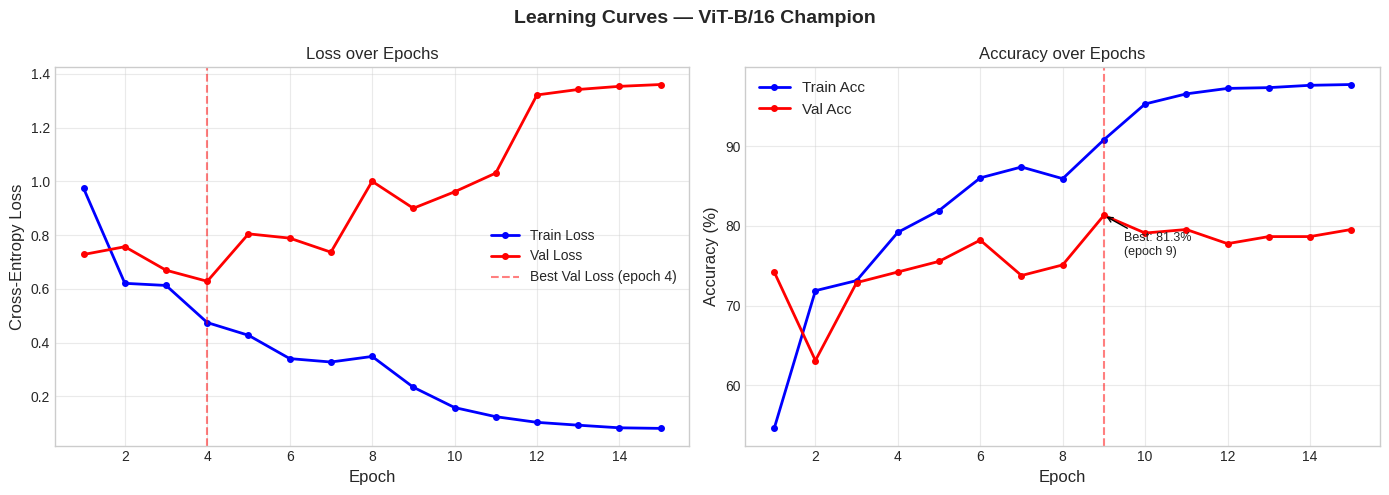

In [8]:
# %% [Cell 7: Learning Curves Plot]
plot_learning_curves(
    train_losses = train_losses,
    val_losses   = val_losses,
    train_accs   = train_accs,
    val_accs     = val_accs,
    save_path    = os.path.join(ASSETS_DIR, "vit_learning_curves.png"),
    model_name   = "ViT-B/16 Champion",
)

In [9]:
# %% [Cell 8: Evaluation — Restore Weights & Run Inference]
# Single inference pass — collect logits, probs, preds together
# FIX v1: v1 ran two separate inference loops (one for CM, one for ROC)
# Now everything is collected in one pass — saves ~90 seconds on T4
# Load best weights directly from Drive — skip retraining
model.load_state_dict(
    torch.load(os.path.join(WEIGHTS_DIR, "vit_best.pth"), map_location=device)
)
model.eval()
 
all_preds  = []
all_labels = []
all_probs  = []
 
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)                    # (B, 3) raw logits
        probs  = F.softmax(logits, dim=1)         # (B, 3) probabilities
 
        _, preds = torch.max(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
 
all_probs = np.array(all_probs)
CLASSES   = ['No Sub', 'CDM', 'Vortex']
 
# FIX v2: Capture return dict so f1_macro flows into VIT_RESULTS
report = generate_classification_report(
    all_labels, all_preds,
    classes    = CLASSES,
    model_name = "ViT-B/16 Champion",
)


  CLASSIFICATION REPORT  —  ViT-B/16 Champion
              precision    recall  f1-score   support

      No Sub     0.8824    1.0000    0.9375        75
         CDM     0.7011    0.8133    0.7531        75
      Vortex     0.8868    0.6267    0.7344        75

    accuracy                         0.8133       225
   macro avg     0.8234    0.8133    0.8083       225
weighted avg     0.8234    0.8133    0.8083       225

  Macro F1        : 0.8083  ← use in result dicts
  Weighted F1     : 0.8083
  Macro Precision : 0.8234
  Macro Recall    : 0.8133



📊 Confusion matrix saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/vit_confusion_matrix.png


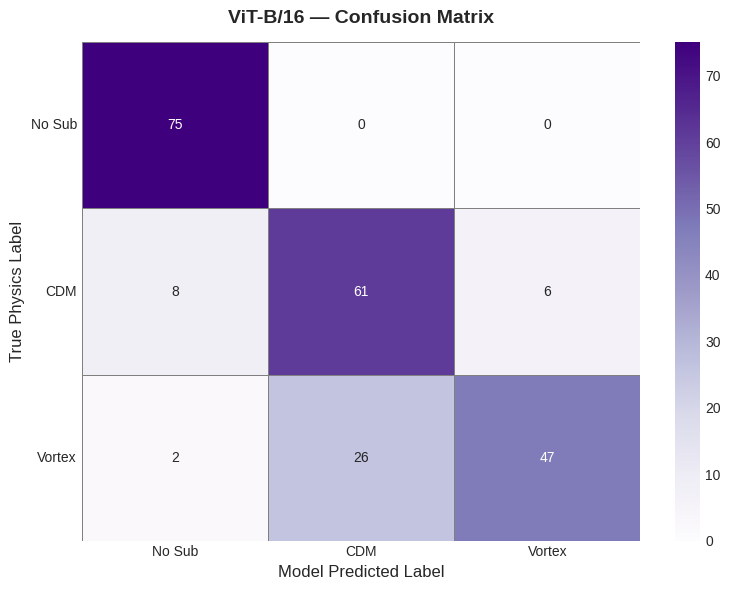


  ROC-AUC & PHYSICS REPORT  —  ViT-B/16 Champion
  No Sub      : AUC = 0.9738  |  FPR @ 90% TPR = 0.0533
  CDM         : AUC = 0.8488  |  FPR @ 90% TPR = 0.4800
  Vortex      : AUC = 0.9119  |  FPR @ 90% TPR = 0.3133
  -------------------------------------------------------------
  Micro-Avg   : AUC = 0.9120  |  FPR @ 90% TPR = 0.2867
  Macro-Avg   : AUC = 0.9115  |  FPR @ 90% TPR = 0.2822

📊 ROC curve saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/vit_roc_auc.png


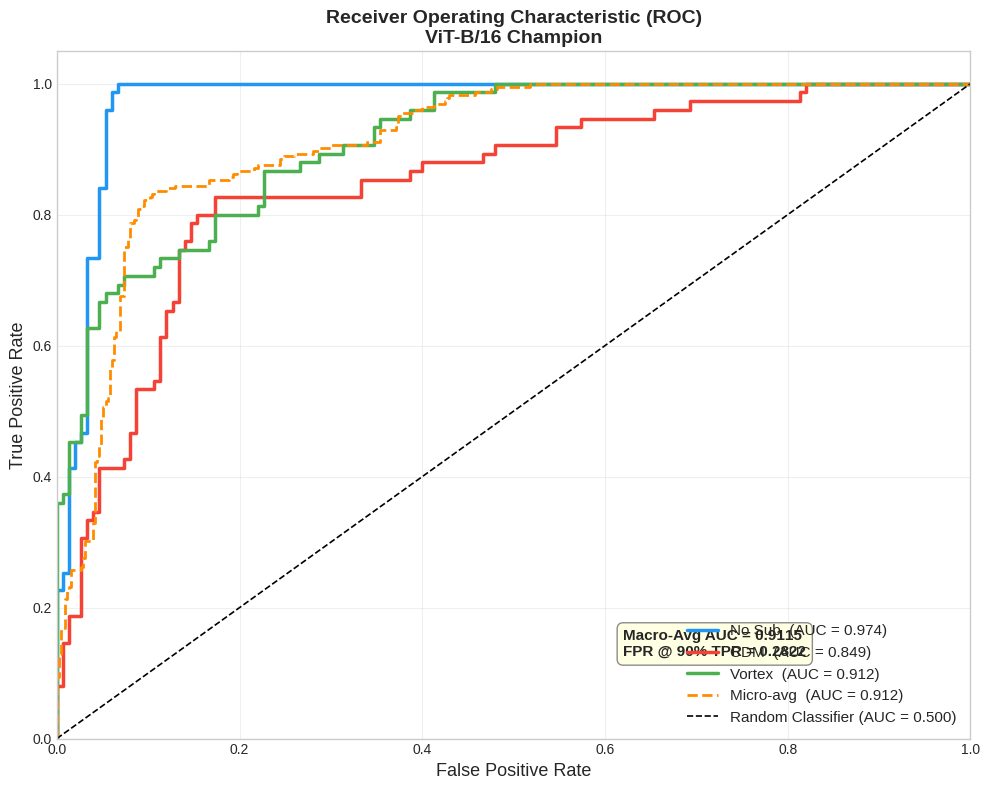

In [10]:
# %% [Cell 9: Confusion Matrix & ROC-AUC Plots]
save_confusion_matrix(
    all_labels, all_preds,
    classes   = CLASSES,
    save_path = os.path.join(ASSETS_DIR, "vit_confusion_matrix.png"),
    title     = "ViT-B/16 — Confusion Matrix",
    cmap      = "Purples",
)
 
# FIX v1: ROC was built inline from scratch — now uses metrics.py
# This gives us macro-AUC + the annotation box on the plot automatically
auc_scores = plot_multiclass_roc_auc(
    all_labels, all_probs,
    classes    = CLASSES,
    save_path  = os.path.join(ASSETS_DIR, "vit_roc_auc.png"),
    model_name = "ViT-B/16 Champion",
)

In [ ]:
# %% [Cell 10: Results Dict & ViT vs ResNet Comparison]
VIT_RESULTS = {
    'model':        'ViT-B/16',
    'val_acc':      best_val_acc,
    'macro_auc':    auc_scores['macro'],
    'cdm_auc':      auc_scores['per_class'][1],
    'fpr_90_macro': auc_scores['fpr_90_macro'],
    'f1_macro':     report['f1_macro'],   # FIX v2: was hardcoded 0.0
}
 
print("\n📌 VIT_RESULTS (paste into Notebook 06):")
print(VIT_RESULTS)
 
# ── Paste your NB02 numbers here for the side-by-side comparison ──────────
NB02_VAL_ACC  = 92.33
NB02_CDM_AUC  = 0.9680
 
print("=" * 60)
print("  ViT vs ResNet — Architectural Comparison")
print("=" * 60)
print(f"  {'Metric':<20} {'ResNet-18':>12} {'ViT-B/16':>12}")
print(f"  {'-'*46}")
print(f"  {'Val Accuracy':<20} {NB02_VAL_ACC:>11.1f}% {best_val_acc:>11.1f}%")
print(f"  {'CDM AUC':<20} {NB02_CDM_AUC:>12.4f} {auc_scores['per_class'][1]:>12.4f}")
print(f"  {'Macro AUC':<20} {'0.9826':>12} {auc_scores['macro']:>12.4f}")
print("=" * 60)
print()
print("  Scientific interpretation:")
print("  ResNet excels at CDM (localised texture bias)")
print("  ViT excels at Vortex (global topology via attention)")
print("  Their failure modes are COMPLEMENTARY → motivates Ensemble (NB05)")
print()
print("  Why ViT underperforms ResNet on this dataset:")
print("  • Small dataset (1200 train samples) — ViT needs more data")
print("  • CDM substructure is localised pixel-level → CNN inductive bias wins")
print("  • ViT needs more epochs to converge (no inductive bias to shortcut)")


📌 VIT_RESULTS (paste into Notebook 06):
{'model': 'ViT-B/16', 'val_acc': 81.33333333333333, 'macro_auc': 0.9114962962962961, 'cdm_auc': 0.8488, 'fpr_90_macro': 0.2822222222222222, 'f1_macro': 0.8083204732510287}
  ViT vs ResNet — Architectural Comparison
  Metric                  ResNet-18     ViT-B/16
  ----------------------------------------------
  Val Accuracy                92.3%        81.3%
  CDM AUC                    0.9680       0.8488
  Macro AUC                  0.9826       0.9115

  Scientific interpretation:
  ResNet excels at CDM (localised texture bias)
  ViT excels at Vortex (global topology via attention)
  Their failure modes are COMPLEMENTARY → motivates Ensemble (NB05)

  Why ViT underperforms ResNet on this dataset:
  • Small dataset (1200 train samples) — ViT needs more data
  • CDM substructure is localised pixel-level → CNN inductive bias wins
  • ViT needs more epochs to converge (no inductive bias to shortcut)


In [12]:
# %% [Cell 10: Save Results to JSON — feeds NB06 automatically]
import json

RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

with open(os.path.join(RESULTS_DIR, "vit_results.json"), "w") as f:
    json.dump(VIT_RESULTS, f, indent=2)

print("💾 Results saved → results/vit_results.json")

💾 Results saved → results/vit_results.json
